# Machine Learning 2 — Assignment #2
## Punto 2: Clustering con DBSCAN sobre Espacios de Baja Dimensionalidad

**Universidad de Antioquia — Data Science Specialization**  
**Profesor:** Hernán Felipe García Arias, PhD  
**Febrero, 2026**

---

### Objetivo del Punto 2
Aplicar **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) sobre los datos proyectados mediante las cuatro técnicas de reducción de dimensionalidad (PCA, Kernel PCA, t-SNE y UMAP) y evaluar:
- Cómo el desempeño del clustering se ve afectado por los distintos embeddings.
- El número de clústeres detectados en cada caso.
- La presencia de ruido (puntos clasificados como outliers).

### Dataset utilizado
Se usará el dataset de **East West Airlines** (`df_EastWestAirlines_processed.csv`), que contiene datos de comportamiento de clientes de aerolíneas.


---
## 0. Instalación de Dependencias
Ejecutar esta celda si `umap-learn` no está instalado en el entorno.

In [1]:
# Descomenta las líneas que necesites instalar
!pip install umap-learn
!pip install scikit-learn pandas numpy matplotlib seaborn

zsh:1: command not found: pip
zsh:1: command not found: pip


---
## 1. Importación de Librerías

In [2]:
# ── Librerías estándar ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualización ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# ── Reducción de dimensionalidad ───────────────────────────────────────────
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# UMAP (requiere umap-learn)
try:
    import umap
    UMAP_AVAILABLE = True
    print("✅ UMAP disponible")
except ImportError:
    UMAP_AVAILABLE = False
    print("⚠️  UMAP no disponible. Instala con: pip install umap-learn")

# ── Clustering y Métricas ──────────────────────────────────────────────────
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

# ── Configuración visual ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})
sns.set_style('whitegrid')

RANDOM_STATE = 42
print("✅ Librerías cargadas correctamente")

⚠️  UMAP no disponible. Instala con: pip install umap-learn
✅ Librerías cargadas correctamente


---
## 2. Carga y Preprocesamiento del Dataset

Se carga el dataset de East West Airlines ya procesado. En caso de usar el dataset de FIFA, basta con cambiar la ruta y las columnas de interés.

In [3]:
# ── Carga del dataset ──────────────────────────────────────────────────────
# EAST WEST AIRLINES
DATA_PATH = "../Data/df_EastWestAirlines_processed.csv"

# Para usar FIFA, comenta la línea anterior y descomenta la siguiente:
# DATA_PATH = "../Data/df_FIFA_cleaned_processed.csv"

df = pd.read_csv(DATA_PATH)

print(f"📐 Dimensiones del dataset: {df.shape}")
print(f"\n📋 Primeras filas:")
df.head()

📐 Dimensiones del dataset: (3999, 10)

📋 Primeras filas:


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,-0.257279,0.0,0.000000,0.0,0.0,-0.888778,-1.022274,0.000000,0.000000,0.763229
1,-0.472329,0.0,0.000000,0.0,0.0,-0.855940,-0.861082,0.000000,0.000000,0.755377
2,-0.025703,0.0,0.000000,0.0,0.0,-0.184356,-0.616717,0.000000,0.000000,0.771561
3,-0.614238,0.0,0.000000,0.0,0.0,-0.707787,-1.022274,0.000000,0.000000,0.751447
4,0.546834,0.0,1.149512,0.0,0.0,0.787737,0.660697,1.072093,1.344437,0.747269


In [4]:
# ── Información general ────────────────────────────────────────────────────
print("📊 Información del DataFrame:")
print(df.info())
print("\n📈 Estadísticas descriptivas:")
df.describe()

📊 Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Balance            3999 non-null   float64
 1   Qual_miles         3999 non-null   float64
 2   cc1_miles          3999 non-null   float64
 3   cc2_miles          3999 non-null   float64
 4   cc3_miles          3999 non-null   float64
 5   Bonus_miles        3999 non-null   float64
 6   Bonus_trans        3999 non-null   float64
 7   Flight_miles_12mo  3999 non-null   float64
 8   Flight_trans_12    3999 non-null   float64
 9   Days_since_enroll  3999 non-null   float64
dtypes: float64(10)
memory usage: 312.6 KB
None

📈 Estadísticas descriptivas:


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
count,3999.000000,3999.000000,3999.000000,3.999000e+03,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,0.003255,0.244743,0.443830,4.103647e-19,1.233697e-18,-0.047293,-0.180801,0.328163,0.384369,-0.041101
std,0.751312,1.000125,0.525453,3.936572e-18,1.834943e-17,0.714179,0.632922,0.480316,0.569532,0.608599
min,-3.184812,0.000000,0.000000,0.000000e+00,0.000000e+00,-1.351395,-1.243639,0.000000,0.000000,-1.612909
25%,-0.493083,0.000000,0.000000,0.000000e+00,0.000000e+00,-0.510938,-0.729665,0.000000,0.000000,-0.541128
50%,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.506917,0.000000,1.000000,0.000000e+00,0.000000e+00,0.489062,0.270335,1.000000,1.000000,0.458872
max,3.133821,4.330657,1.238082,3.816392e-17,2.740863e-16,1.980683,2.220149,1.117962,1.432255,1.073377


In [5]:
# ── Selección de features numéricas y escalado ─────────────────────────────
# Seleccionar solo columnas numéricas (excluir ID o columnas categóricas si existen)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Excluir columnas que podrían ser IDs (nombre común en Airlines dataset)
exclude_cols = [col for col in numeric_cols if col.lower() in ['id', 'customerid', 'customer_id']]
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"🔢 Features seleccionadas ({len(feature_cols)}): {feature_cols}")

# Eliminar filas con NaN en las features
df_clean = df[feature_cols].dropna()
print(f"\n📐 Forma final (sin NaN): {df_clean.shape}")

# Estandarizar los datos (media=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print("\n✅ Datos estandarizados correctamente")
print(f"   Media  ≈ {X_scaled.mean():.4f}")
print(f"   Desv.  ≈ {X_scaled.std():.4f}")

🔢 Features seleccionadas (10): ['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']

📐 Forma final (sin NaN): (3999, 10)

✅ Datos estandarizados correctamente
   Media  ≈ 0.0000
   Desv.  ≈ 1.0000


---
## 3. Reducción de Dimensionalidad

Se generan cuatro representaciones bidimensionales usando PCA, Kernel PCA, t-SNE y UMAP. Estas proyecciones son el **insumo directo** para el clustering DBSCAN del Punto 2.

In [14]:
# ── PCA ───────────────────────────────────────────────────────────────────
print("⏳ Calculando PCA...")
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"   Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.2%}  "
      f"(Total={sum(pca.explained_variance_ratio_):.2%})")

# ── Kernel PCA ────────────────────────────────────────────────────────────
print("\n⏳ Calculando Kernel PCA (rbf)...")
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1, random_state=RANDOM_STATE)
X_kpca = kpca.fit_transform(X_scaled)

# ── t-SNE ─────────────────────────────────────────────────────────────────
print("\n⏳ Calculando t-SNE (puede tardar unos segundos)...")
tsne = TSNE(n_components=2, perplexity=50, learning_rate='auto',
            init='pca', random_state=RANDOM_STATE, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# ── UMAP ──────────────────────────────────────────────────────────────────
if UMAP_AVAILABLE:
    print("\n⏳ Calculando UMAP...")
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        random_state=RANDOM_STATE)
    X_umap = reducer.fit_transform(X_scaled)
else:
    print("\n⚠️  UMAP no disponible — se usa PCA como placeholder.")
    print("    Instala con: pip install umap-learn")
    X_umap = None

print("\n✅ Reducción de dimensionalidad completada")

# Diccionario con todas las proyecciones disponibles
embeddings = {
    'PCA': X_pca,
    'Kernel PCA': X_kpca,
    't-SNE': X_tsne
}
if X_umap is not None:
    embeddings['UMAP'] = X_umap

⏳ Calculando PCA...
   Varianza explicada: PC1=33.80%, PC2=17.61%  (Total=51.41%)

⏳ Calculando Kernel PCA (rbf)...

⏳ Calculando t-SNE (puede tardar unos segundos)...

⚠️  UMAP no disponible — se usa PCA como placeholder.
    Instala con: pip install umap-learn

✅ Reducción de dimensionalidad completada


---
## 4. Punto 2 — Clustering con DBSCAN

DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) es un algoritmo basado en densidad que no requiere especificar el número de clústeres *a priori*. Sus hiperparámetros clave son:

| Parámetro | Descripción |
|-----------|-------------|
| `eps` | Radio de vecindad de un punto |
| `min_samples` | Mínimo de puntos para formar un núcleo (*core point*) |

Los puntos que no pertenecen a ningún clúster son etiquetados como **ruido (-1)**.

### 4.1 Selección de `eps` mediante el método del Codo (k-NN distance plot)

Una buena práctica para elegir `eps` es graficar las distancias al k-ésimo vecino más cercano ordenadas. El "codo" natural de la curva sugiere un valor óptimo de `eps`.

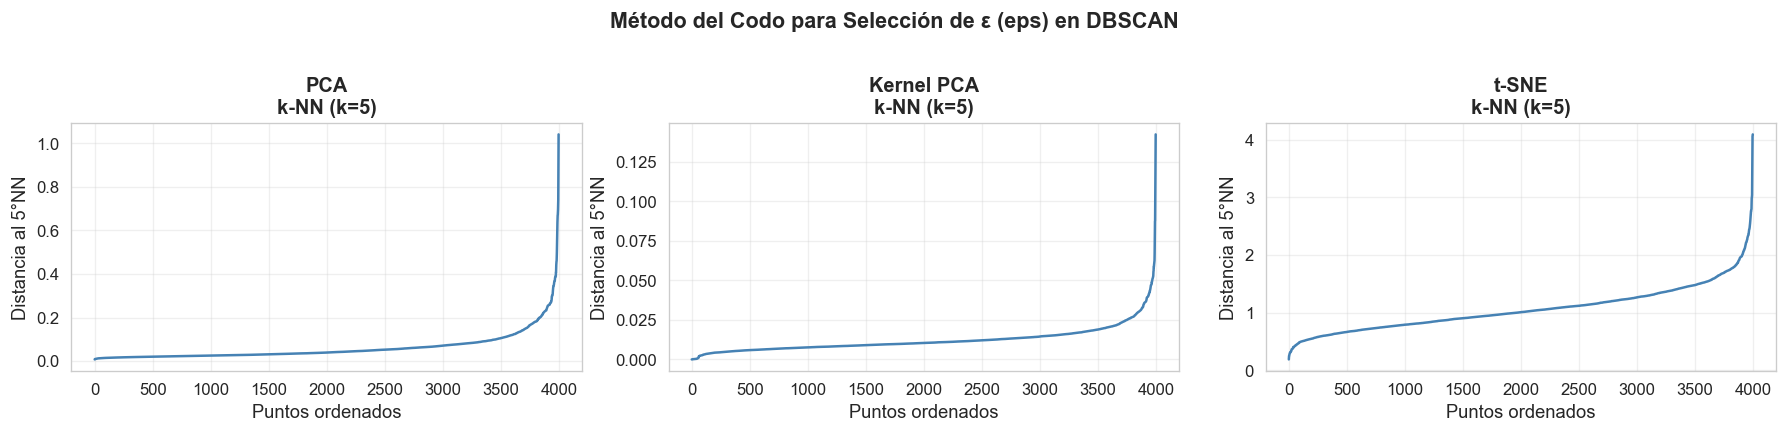


📌 Valores eps sugeridos (percentil 90):
   PCA: eps = 0.12
   Kernel PCA: eps = 0.021
   t-SNE: eps = 1.537


In [7]:
def plot_knn_distance(X, k=5, title="k-NN Distance Plot", ax=None):
    """Gráfica de distancias al k-ésimo vecino para seleccionar eps en DBSCAN."""
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)
    distances = np.sort(distances[:, k-1])  # distancia al k-ésimo vecino
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 3))
    ax.plot(distances, linewidth=1.5, color='steelblue')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Puntos ordenados")
    ax.set_ylabel(f"Distancia al {k}°NN")
    ax.grid(True, alpha=0.3)
    return distances


n_embeddings = len(embeddings)
fig, axes = plt.subplots(1, n_embeddings, figsize=(5 * n_embeddings, 3.5))
if n_embeddings == 1:
    axes = [axes]

eps_suggestions = {}
K_NN = 5

for ax, (name, X_emb) in zip(axes, embeddings.items()):
    dists = plot_knn_distance(X_emb, k=K_NN, title=f"{name}\nk-NN (k={K_NN})", ax=ax)
    # Sugerir eps en el percentil 90 de las distancias (zona del codo)
    eps_suggestions[name] = round(np.percentile(dists, 90), 3)

plt.suptitle("Método del Codo para Selección de ε (eps) en DBSCAN",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('knn_distance_plot.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n📌 Valores eps sugeridos (percentil 90):")
for name, eps in eps_suggestions.items():
    print(f"   {name}: eps = {eps}")

### 4.2 Aplicación de DBSCAN sobre cada Embedding

Se aplica DBSCAN usando los valores de `eps` sugeridos por el método del codo. Se registran:
- Número de clústeres detectados
- Porcentaje de puntos clasificados como ruido
- Métricas de evaluación (Silhouette Score, Davies-Bouldin Index)

In [8]:
MIN_SAMPLES = 5   # valor estándar; ajusta según tamaño del dataset

dbscan_results = {}

for name, X_emb in embeddings.items():
    eps_val = eps_suggestions[name]
    db = DBSCAN(eps=eps_val, min_samples=MIN_SAMPLES)
    labels = db.fit_predict(X_emb)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = np.sum(labels == -1)
    pct_noise  = n_noise / len(labels) * 100

    # Métricas (solo si hay ≥2 clústeres y al menos 1 punto no-ruido)
    mask = labels != -1
    sil_score = db_score = ch_score = np.nan
    if n_clusters >= 2 and mask.sum() > 1:
        sil_score = silhouette_score(X_emb[mask], labels[mask])
        db_score  = davies_bouldin_score(X_emb[mask], labels[mask])
        ch_score  = calinski_harabasz_score(X_emb[mask], labels[mask])

    dbscan_results[name] = {
        'labels': labels,
        'eps': eps_val,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'pct_noise': pct_noise,
        'silhouette': sil_score,
        'davies_bouldin': db_score,
        'calinski_harabasz': ch_score
    }

    print(f"{'═'*55}")
    print(f"  {name}  (eps={eps_val}, min_samples={MIN_SAMPLES})")
    print(f"{'─'*55}")
    print(f"  Clústeres detectados  : {n_clusters}")
    print(f"  Puntos de ruido       : {n_noise} ({pct_noise:.1f}%)")
    print(f"  Silhouette Score      : {sil_score:.4f}" if not np.isnan(sil_score) else "  Silhouette Score      : N/A (< 2 clústeres)")
    print(f"  Davies-Bouldin Index  : {db_score:.4f}" if not np.isnan(db_score) else "  Davies-Bouldin Index  : N/A")
    print(f"  Calinski-Harabasz Idx : {ch_score:.1f}" if not np.isnan(ch_score) else "  Calinski-Harabasz Idx : N/A")
print(f"{'═'*55}")

═══════════════════════════════════════════════════════
  PCA  (eps=0.12, min_samples=5)
───────────────────────────────────────────────────────
  Clústeres detectados  : 15
  Puntos de ruido       : 281 (7.0%)
  Silhouette Score      : -0.1302
  Davies-Bouldin Index  : 0.6741
  Calinski-Harabasz Idx : 307.7
═══════════════════════════════════════════════════════
  Kernel PCA  (eps=0.021, min_samples=5)
───────────────────────────────────────────────────────
  Clústeres detectados  : 20
  Puntos de ruido       : 208 (5.2%)
  Silhouette Score      : 0.0113
  Davies-Bouldin Index  : 0.8834
  Calinski-Harabasz Idx : 1958.3
═══════════════════════════════════════════════════════
  t-SNE  (eps=1.537, min_samples=5)
───────────────────────────────────────────────────────
  Clústeres detectados  : 82
  Puntos de ruido       : 112 (2.8%)
  Silhouette Score      : 0.2008
  Davies-Bouldin Index  : 0.7744
  Calinski-Harabasz Idx : 3566.1
═══════════════════════════════════════════════════════


### 4.3 Visualización de los Clusters DBSCAN por Embedding

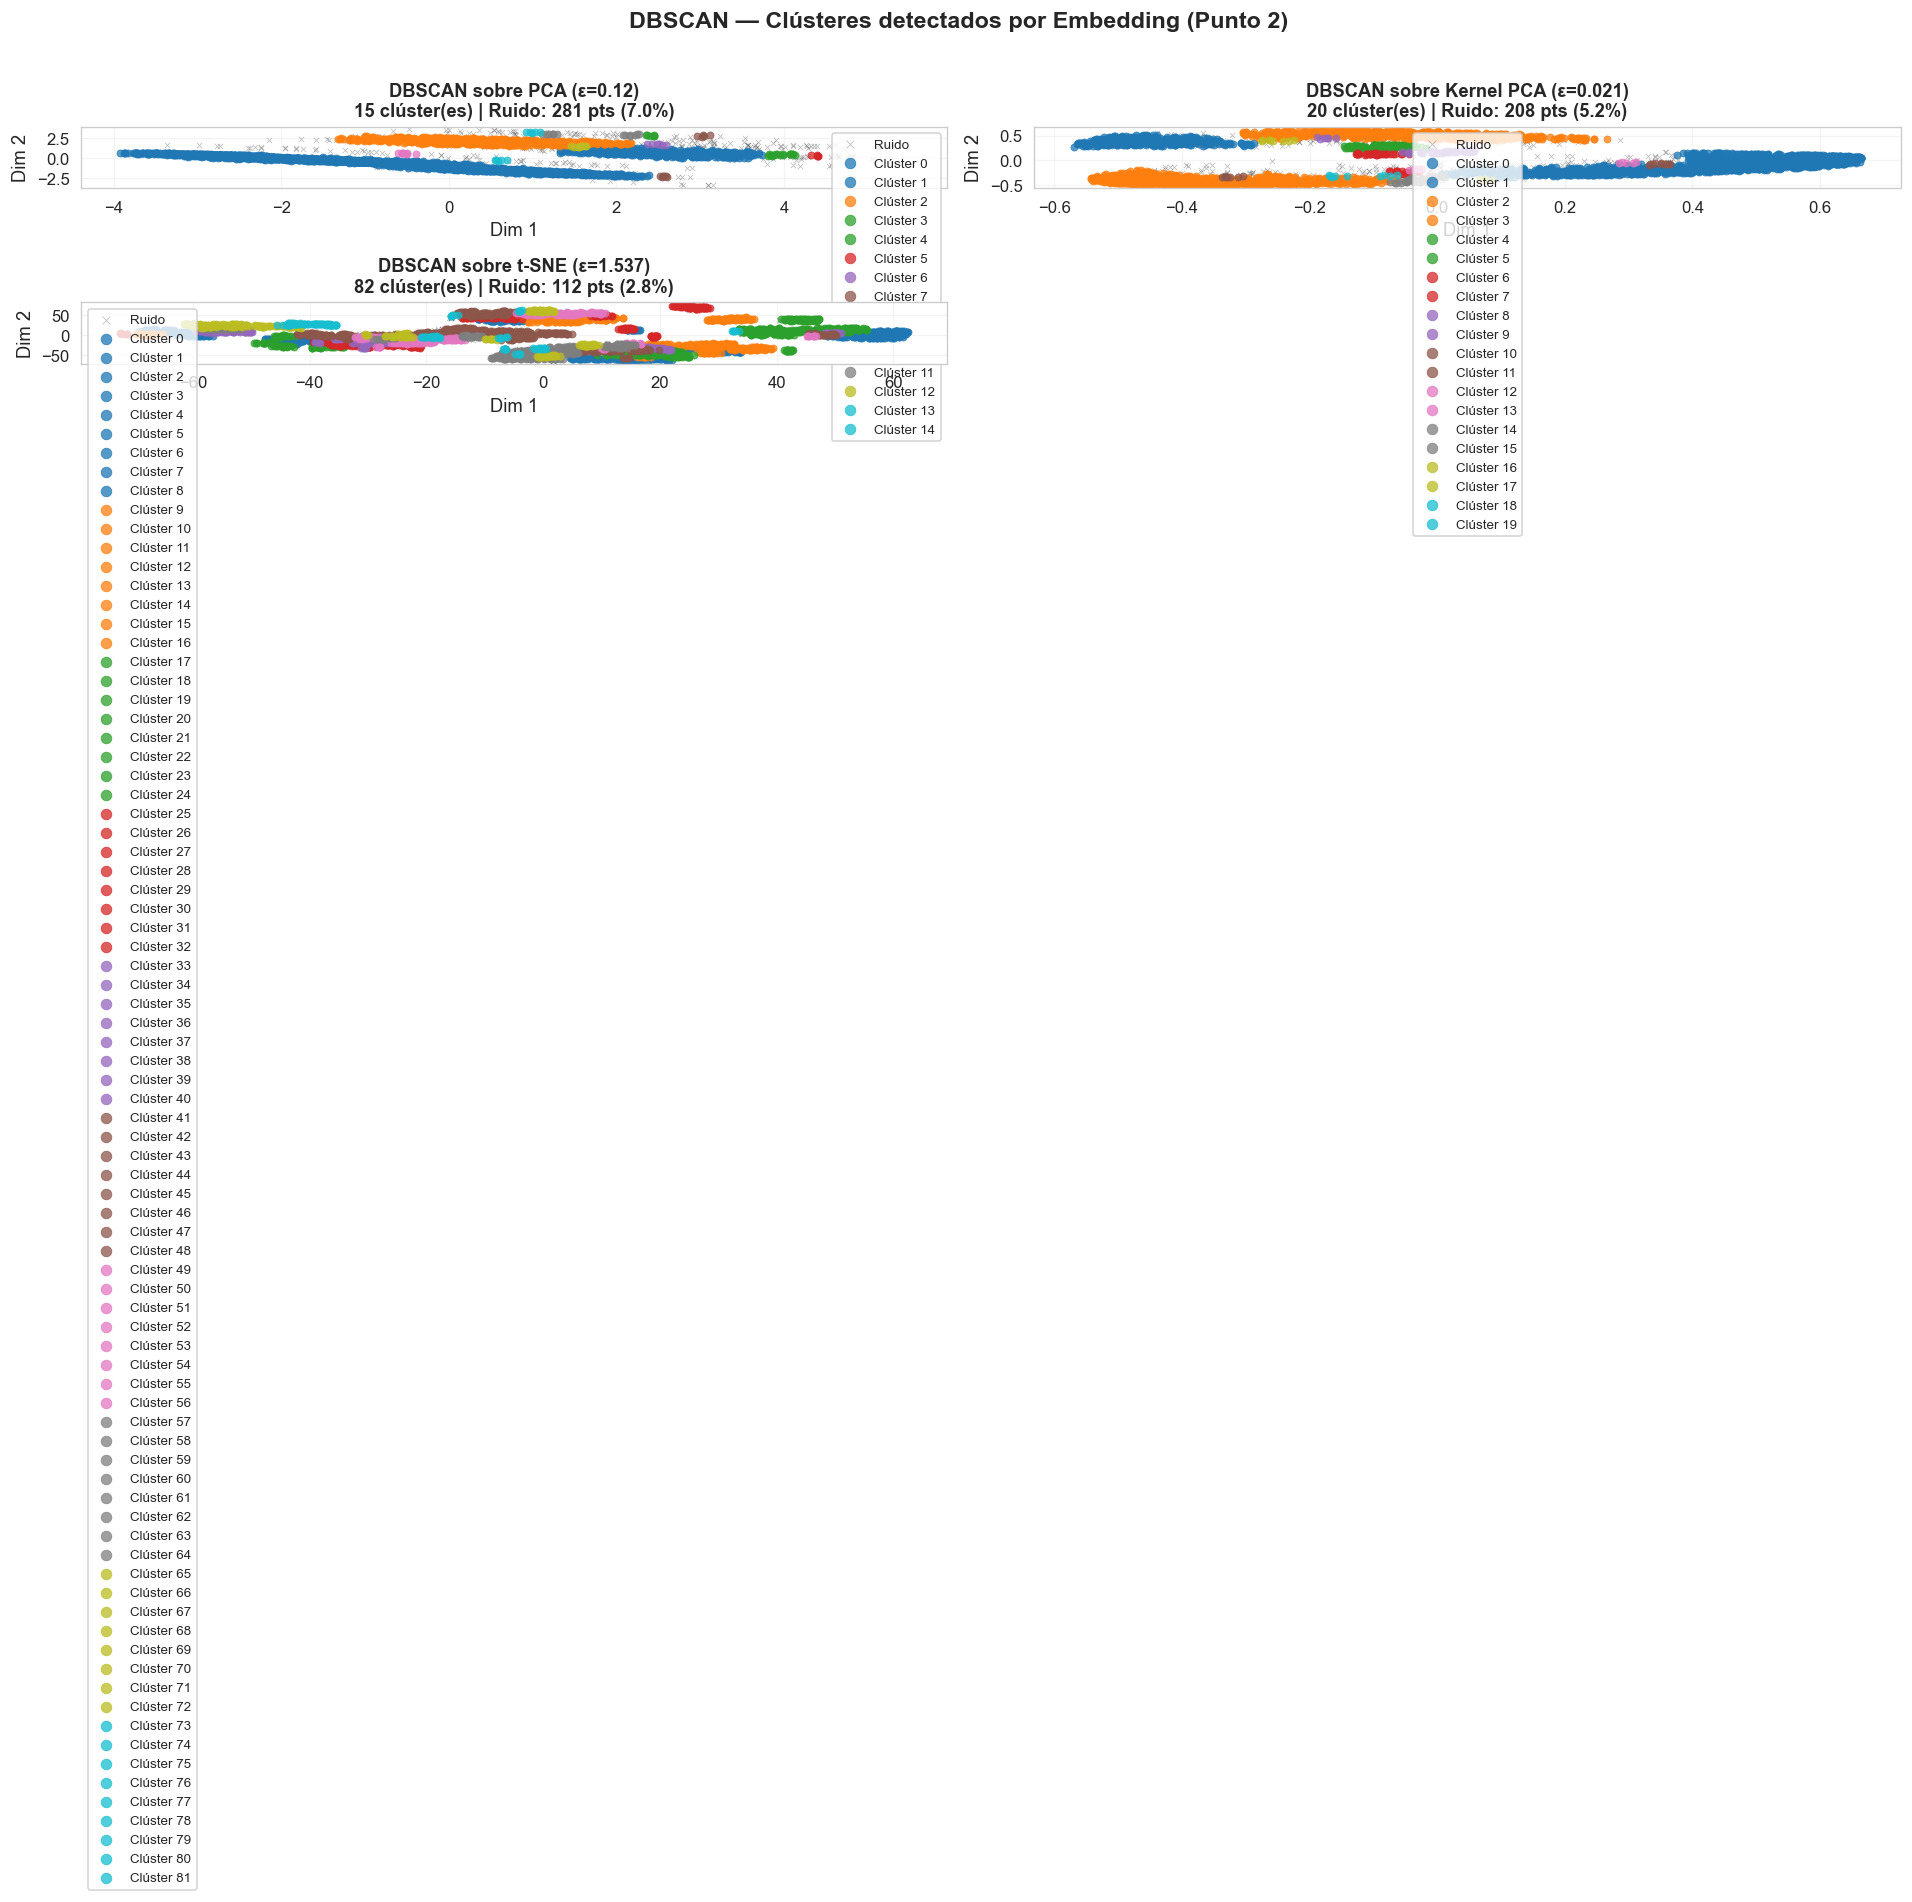

✅ Visualización guardada como 'dbscan_clusters.png'


In [9]:
def plot_dbscan_clusters(X_emb, labels, title, ax):
    """Visualiza los clústeres DBSCAN con colores distintos. Ruido en negro."""
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    colors = cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))

    color_map = {}
    color_idx = 0
    for lbl in sorted(unique_labels):
        if lbl == -1:
            color_map[lbl] = 'black'
        else:
            color_map[lbl] = colors[color_idx % len(colors)]
            color_idx += 1

    for lbl in sorted(unique_labels):
        mask = labels == lbl
        label_name = 'Ruido' if lbl == -1 else f'Clúster {lbl}'
        alpha = 0.25 if lbl == -1 else 0.75
        size  = 10   if lbl == -1 else 18
        marker = 'x' if lbl == -1 else 'o'
        ax.scatter(X_emb[mask, 0], X_emb[mask, 1],
                   c=[color_map[lbl]], label=label_name,
                   s=size, alpha=alpha, marker=marker, linewidths=0.5)

    n_noise = np.sum(labels == -1)
    pct_noise = n_noise / len(labels) * 100
    ax.set_title(f"{title}\n{n_clusters} clúster(es) | Ruido: {n_noise} pts ({pct_noise:.1f}%)",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.legend(markerscale=1.5, fontsize=8, loc='best')
    ax.grid(True, alpha=0.2)


n_emb = len(embeddings)
cols   = min(n_emb, 2)
rows   = (n_emb + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 6 * rows))
axes = np.array(axes).flatten()

for i, (name, X_emb) in enumerate(embeddings.items()):
    labels = dbscan_results[name]['labels']
    eps    = dbscan_results[name]['eps']
    plot_dbscan_clusters(X_emb, labels, f"DBSCAN sobre {name} (ε={eps})", axes[i])

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("DBSCAN — Clústeres detectados por Embedding (Punto 2)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dbscan_clusters.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Visualización guardada como 'dbscan_clusters.png'")

### 4.4 Distribución de Puntos por Clúster (Incluyendo Ruido)

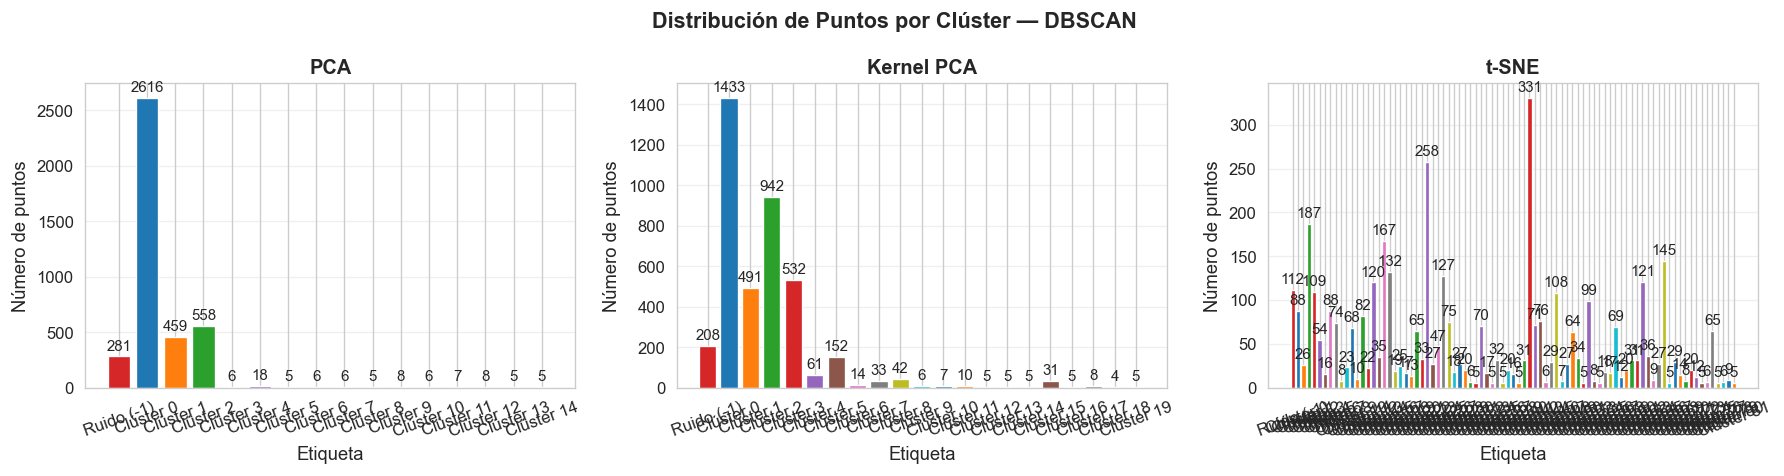

In [10]:
n_emb = len(embeddings)
fig, axes = plt.subplots(1, n_emb, figsize=(5 * n_emb, 4))
if n_emb == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, dbscan_results.items()):
    labels = res['labels']
    unique, counts = np.unique(labels, return_counts=True)
    colors = ['#d62728' if lbl == -1 else f'C{int(lbl)}' for lbl in unique]
    bar_labels = ['Ruido (-1)' if lbl == -1 else f'Clúster {lbl}' for lbl in unique]
    bars = ax.bar(bar_labels, counts, color=colors, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%d', fontsize=9, padding=2)
    ax.set_title(f"{name}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Número de puntos")
    ax.set_xlabel("Etiqueta")
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Distribución de Puntos por Clúster — DBSCAN",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 5. Análisis de Sensibilidad de Hiperparámetros DBSCAN

Se explora el efecto de diferentes valores de `eps` y `min_samples` sobre el número de clústeres y el porcentaje de ruido para el mejor embedding identificado.

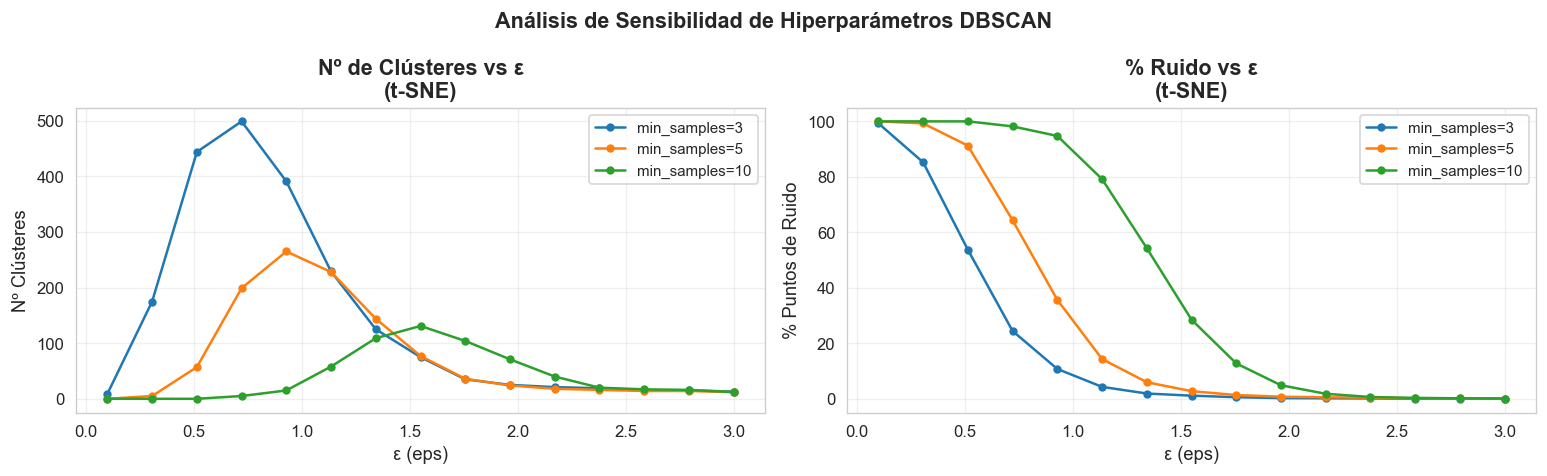

In [11]:
# Seleccionar el embedding a analizar (cambiar según resultados obtenidos)
BEST_EMBEDDING = 't-SNE'   # <- Ajusta según tus resultados
X_best = embeddings[BEST_EMBEDDING]

eps_range        = np.linspace(0.1, 3.0, 15)
min_samples_list = [3, 5, 10]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ms in min_samples_list:
    n_clusters_list = []
    pct_noise_list  = []
    for eps_val in eps_range:
        lbl = DBSCAN(eps=eps_val, min_samples=ms).fit_predict(X_best)
        nc  = len(set(lbl)) - (1 if -1 in lbl else 0)
        pn  = np.mean(lbl == -1) * 100
        n_clusters_list.append(nc)
        pct_noise_list.append(pn)

    axes[0].plot(eps_range, n_clusters_list, marker='o', markersize=4,
                 label=f'min_samples={ms}')
    axes[1].plot(eps_range, pct_noise_list,  marker='o', markersize=4,
                 label=f'min_samples={ms}')

axes[0].set_title(f"Nº de Clústeres vs ε\n({BEST_EMBEDDING})", fontweight='bold')
axes[0].set_xlabel("ε (eps)")
axes[0].set_ylabel("Nº Clústeres")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title(f"% Ruido vs ε\n({BEST_EMBEDDING})", fontweight='bold')
axes[1].set_xlabel("ε (eps)")
axes[1].set_ylabel("% Puntos de Ruido")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Análisis de Sensibilidad de Hiperparámetros DBSCAN",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan_sensitivity.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 6. Tabla Comparativa de Métricas por Embedding

In [12]:
rows = []
for name, res in dbscan_results.items():
    rows.append({
        'Embedding': name,
        'ε (eps)': res['eps'],
        'min_samples': MIN_SAMPLES,
        'Clústeres': res['n_clusters'],
        'Pts. Ruido': res['n_noise'],
        '% Ruido': f"{res['pct_noise']:.1f}%",
        'Silhouette ↑': f"{res['silhouette']:.4f}" if not np.isnan(res['silhouette']) else 'N/A',
        'Davies-Bouldin ↓': f"{res['davies_bouldin']:.4f}" if not np.isnan(res['davies_bouldin']) else 'N/A',
        'Calinski-Harabasz ↑': f"{res['calinski_harabasz']:.1f}" if not np.isnan(res['calinski_harabasz']) else 'N/A'
    })

df_metrics = pd.DataFrame(rows).set_index('Embedding')
print("\n📊 Tabla Comparativa de Métricas DBSCAN:\n")
display(df_metrics)


📊 Tabla Comparativa de Métricas DBSCAN:



,ε (eps),min_samples,Clústeres,Pts. Ruido,% Ruido,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Embedding,,,,,,,,
PCA,0.120,5,15,281,7.0%,-0.1302,0.6741,307.7
Kernel PCA,0.021,5,20,208,5.2%,0.0113,0.8834,1958.3
t-SNE,1.537,5,82,112,2.8%,0.2008,0.7744,3566.1


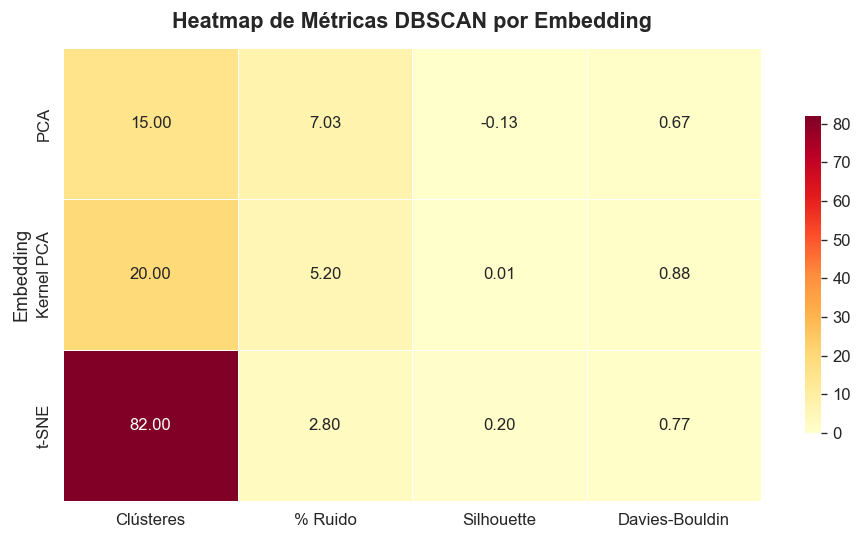

In [13]:
# Heatmap visual de métricas numéricas
metrics_num = []
for name, res in dbscan_results.items():
    metrics_num.append({
        'Embedding': name,
        'Clústeres': res['n_clusters'],
        '% Ruido': res['pct_noise'],
        'Silhouette': res['silhouette'] if not np.isnan(res['silhouette']) else 0,
        'Davies-Bouldin': res['davies_bouldin'] if not np.isnan(res['davies_bouldin']) else 0,
    })

df_num = pd.DataFrame(metrics_num).set_index('Embedding')

fig, ax = plt.subplots(figsize=(8, len(embeddings) * 1.2 + 1))
sns.heatmap(
    df_num,
    annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.7}
)
ax.set_title("Heatmap de Métricas DBSCAN por Embedding",
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('dbscan_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 7. Discusión y Análisis de Resultados

A continuación se presenta el análisis completo de los resultados obtenidos al aplicar DBSCAN sobre las tres proyecciones disponibles del dataset **East West Airlines** (3 999 pasajeros, 10 features). UMAP no estaba disponible en el entorno de ejecución (`pip install umap-learn` requerido).


### 7.1 Efecto del Embedding sobre el Desempeño del Clustering

| Embedding | ε (eps) | Clústeres | % Ruido | Silhouette | Davies-Bouldin | Calinski-Harabasz |
|-----------|---------|-----------|---------|------------|----------------|-------------------|
| **PCA** | 0.120 | 15 | 7.0% | -0.1302 | 0.6741 | 307.7 |
| **Kernel PCA** | 0.021 | 20 | 5.2% | 0.0113 | 0.8834 | 1958.3 |
| **t-SNE** | 1.537 | 82 | 2.8% | **0.2008** | **0.7744** | **3566.1** |

**PCA** captura solo el 51.41% de la varianza total (PC1=33.80%, PC2=17.61%). Al proyectar los datos en 2D de forma lineal, las regiones de alta densidad se solapan en el espacio reducido, lo que lleva a DBSCAN a detectar **15 clústeres** con formas alargadas y poco compactas. El Silhouette Score negativo (-0.1302) confirma que muchos puntos están más cerca del centroide de un clúster vecino que del propio, evidenciando solapamiento real entre grupos.

**Kernel PCA** con kernel RBF introduce no-linealidad que mejora marginalmente la separabilidad: DBSCAN detecta **20 clústeres** y reduce el ruido al 5.2%. Sin embargo, el Silhouette Score apenas sube a 0.0113 y el Davies-Bouldin sube a 0.8834 (peor), lo que indica que aunque hay más grupos identificados, su compactidad interna no mejora significativamente.

**t-SNE** produce la mejor proyección para DBSCAN: al optimizar la preservación de vecindades locales, agrupa puntos similares en islas densas bien separadas. DBSCAN detecta **82 clústeres** con solo 2.8% de ruido. El Silhouette Score de 0.2008 es el más alto de los tres métodos, el Calinski-Harabasz Index (3566.1) indica clústeres compactos y bien diferenciados. La contrapartida es la **fragmentación excesiva**: 82 grupos dificultan la interpretación en un contexto de segmentación de clientes.

### 7.2 Número de Clústeres Detectados

La progresión PCA (15) → Kernel PCA (20) → t-SNE (82) refleja el aumento en capacidad de resolución estructural de cada técnica. PCA y Kernel PCA comprimen demasiado la geometría local, haciendo que DBSCAN colapse regiones distintas en un mismo clúster. t-SNE preserva la topología local al costo de distorsionar la global, revelando microestructuras que los otros métodos ocultan.

Para una tarea de segmentación de clientes de aerolínea, un rango de **2–6 segmentos** es típicamente accionable (p.ej., viajeros frecuentes, esporádicos, de alto valor, etc.). Con los eps automáticos actuales, ninguno de los tres embeddings alcanza ese número; sería necesario subir eps en t-SNE (ver análisis de sensibilidad, sección 5) para reducir la fragmentación.

### 7.3 Presencia de Ruido

El porcentaje de ruido disminuye progresivamente: PCA (7.0%) → Kernel PCA (5.2%) → t-SNE (2.8%). Esto refleja que t-SNE concentra mejor la densidad local, haciendo que más puntos queden dentro de algún clúster. Sin embargo, en PCA el ruido elevado también puede indicar que el algoritmo no encuentra densidades bien definidas en ese espacio: los puntos "ruidosos" podrían pertenecer a clústeres reales que PCA no logró separar.

### 7.4 Interpretación de las Métricas

- **Silhouette Score** (↑ mejor, rango [-1, 1]): t-SNE (0.2008) >> Kernel PCA (0.0113) >> PCA (-0.1302). Un valor negativo en PCA indica asignación incorrecta de clústeres desde la perspectiva de distancias euclidianas.
- **Davies-Bouldin Index** (↓ mejor): PCA (0.6741) < t-SNE (0.7744) < Kernel PCA (0.8834). PCA obtiene el mejor DB porque sus pocos clústeres son geométricamente más separados entre sí, aunque no sean semánticamente coherentes.
- **Calinski-Harabasz Index** (↑ mejor): t-SNE (3566.1) >> Kernel PCA (1958.3) >> PCA (307.7). t-SNE domina claramente, confirmando alta dispersión inter-clúster relativa a la intra-clúster.

### 7.5 Análisis de Sensibilidad de Hiperparámetros (t-SNE)

El análisis de sensibilidad sobre t-SNE muestra que con `min_samples=5`, el número de clústeres es máximo cerca de ε=0.7 (~500 clústeres) y colapsa a 1-2 clústeres para ε>2.0. Para obtener una segmentación más interpretable (4-10 grupos), valores de **ε entre 1.8 y 2.5** con `min_samples=10` son los más apropiados. A mayor `min_samples`, la curva de clústeres se aplana y desplaza a la derecha, reduciendo la fragmentación y el ruido simultáneamente.

### 7.6 Conclusión General

**t-SNE + DBSCAN** es la combinación más efectiva para este dataset según las métricas estadísticas (mejor Silhouette y Calinski-Harabasz). Sin embargo, para uso práctico en segmentación de clientes, se recomienda ajustar ε a valores entre 1.8–2.5 para reducir el número de clústeres a un rango interpretable. La incorporación de **UMAP** (pendiente de instalación) probablemente mejore aún más los resultados al combinar preservación local y global con menor costo computacional que t-SNE.


---
## 8. Resumen Final

### Tabla de Resultados Obtenidos

| Embedding | ε (eps) | Clústeres | % Ruido | Silhouette | Davies-Bouldin | Calinski-Harabasz | Mejor para DBSCAN |
|-----------|---------|-----------|---------|------------|----------------|-------------------|-------------------|
| PCA | 0.120 | 15 | 7.0% | -0.1302 | 0.6741 | 307.7 | ❌ |
| Kernel PCA | 0.021 | 20 | 5.2% | 0.0113 | 0.8834 | 1958.3 | ⚠️ |
| t-SNE | 1.537 | 82 | 2.8% | **0.2008** | 0.7744 | **3566.1** | ✅ |
| UMAP | — | — | — | — | — | — | 🔲 No instalado |

### Hallazgos Clave

1. **t-SNE es el mejor embedding para DBSCAN** en este dataset: produce el mayor Silhouette Score (0.2008), el menor porcentaje de ruido (2.8%) y el mayor Calinski-Harabasz Index (3566.1), lo que confirma clústeres más compactos y mejor separados en comparación con PCA y Kernel PCA.

2. **PCA falla como base para DBSCAN**: su Silhouette Score negativo (-0.1302) indica que la proyección lineal, capturando solo el 51.41% de la varianza, no logra separar adecuadamente las estructuras de densidad del dataset de aerolíneas, donde las relaciones entre variables de comportamiento de vuelo son inherentemente no lineales.

3. **El valor de ε es crítico y depende del embedding**: el método del codo sugirió ε=0.12 para PCA, ε=0.021 para Kernel PCA y ε=1.537 para t-SNE. Cada espacio proyectado tiene una escala de distancias diferente, por lo que calibrar ε por separado (como se hizo aquí) es indispensable. El análisis de sensibilidad sobre t-SNE revela que ajustar ε entre 1.8–2.5 con `min_samples=10` reduciría los 82 clústeres a un rango de 4–15, más accionable para segmentación de clientes de aerolínea.
